# Extension: Jiang et al. (2024) — Table 1, Table A1, Figure A1

This notebook extends the main quantitative results from:
> Jiang, E., Matvos, G., Piskorski, T., Seru, A. (2024). "Monetary Tightening
> and U.S. Bank Fragility in 2023: Mark-to-Market Losses and Uninsured Depositor
> Runs?" *Journal of Finance*.

**Methodology (Section II)**:
1. Take Q4 2024 balance sheet snapshot from FFIEC CDR Call Reports
2. Apply Q4 2024 → Q4 2025 ETF price changes to each bank's maturity-bucketed holdings
3. RMBS and first-lien mortgages use an RMBS multiplier = ΔMBS ETF / ΔTreasury Index
4. Treasury/other securities and other loans use direct Treasury ETF price changes
5. Aggregate by bank size category (Small, Large non-GSIB, GSIB)

In [1]:
import sys
sys.path.insert(0, "./src/")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))
FFIEC_REPORT_DATE = config("FFIEC_REPORT_DATE")
FFIEC_MTM_END_DATE = config("FFIEC_MTM_END_DATE")

## Load Pre-Computed Results

`run_analysis.py --source ffiec` (or `doit ffiec`) computes all per-bank
MTM losses using FFIEC data and saves them to `_data/` with `_ffiec` suffix.

In [2]:
bank_losses = pd.read_parquet(DATA_DIR / "bank_losses_ffiec.parquet")
uninsured_ratio = pd.read_parquet(DATA_DIR / "uninsured_ratio_ffiec.parquet")
insured_coverage = pd.read_parquet(DATA_DIR / "insured_coverage_ffiec.parquet")
table1 = pd.read_parquet(DATA_DIR / "table1_ffiec.parquet")
table_a1_a = pd.read_parquet(DATA_DIR / "table_a1_panel_a_ffiec.parquet")
table_a1_b = pd.read_parquet(DATA_DIR / "table_a1_panel_b_ffiec.parquet")

print(f"Banks in sample: {len(bank_losses):,}")
print(f"Aggregate MTM loss: ${bank_losses['total_loss'].abs().sum()/1e6:.1f}B")

Banks in sample: 4,543
Aggregate MTM loss: $270.7B


## Table 1 Extension

**Original paper results** (Jiang et al. Table 1, Q1 2022 → Q1 2023):
| Statistic | All Banks | Small | Large non-GSIB | GSIB |
|-----------|-----------|-------|----------------|------|
| **Aggregate Loss** | 2.2T | 146.0B | 623.2B | 1.4T |
| **Bank-Level Loss** | 28.6M | 22.3M | 306.7M| 9.9B |
| ... | ... | ... | ... | ... |
| Number of Banks | 4,844 | 4,090 | 710 | 44 |

Below we present the extended results using FFIEC Q4 2024 data.

In [3]:
print("=" * 60)
print(f"TABLE 1: MTM Loss Summary ({FFIEC_REPORT_DATE} → {FFIEC_MTM_END_DATE})")
print("=" * 60)
print(table1.to_string())

TABLE 1: MTM Loss Summary (2024-12-31 → 2025-12-31)
                                All Banks   Small  Large non-GSIB  GSIB
Aggregate Loss                      270.7    29.4           146.0  95.4
Bank Level Loss                       6.7     5.0            56.0  88.7
Bank Level Loss Std                   0.9     0.0             0.6  12.4
Share RMBS                            2.8     2.3             5.3   3.5
Share RMBS Std                       12.7    11.9            15.2  26.6
Share Treasury and Other              8.6     9.7             5.5  41.5
Share Treasury and Other Std         17.3    17.3            15.2  39.8
Share Residential Mortgage           19.4    21.2            13.0  14.8
Share Residential Mortgage Std       22.0    22.1            19.4  42.3
Share Other Loan                     55.2    53.1            66.5   0.0
Share Other Loan Std                 24.9    23.9            27.3   0.0
Loss/Asset                            2.2     2.3             1.9   0.2
Loss/Asset S

In [4]:
# Compare to original paper targets (Q1 2022 → Q1 2023)
paper_targets = {
    "All Banks": {"agg_loss_B": 2200, "n_banks": 4844},
    "Small": {"agg_loss_B": 146, "n_banks": 4090},
    "Large non-GSIB": {"agg_loss_B": 623.2, "n_banks": 710},
    "GSIB": {"agg_loss_B": 1400, "n_banks": 44},
}

print(f"\nComparison: Original Paper (Q1 2022→Q1 2023) vs Extension ({FFIEC_REPORT_DATE}→{FFIEC_MTM_END_DATE}):")
for group, targets in paper_targets.items():
    if group in table1.columns:
        our_loss = table1.loc["Aggregate Loss", group]
        our_n = table1.loc["Number of Banks", group]
        print(f"  {group}:")
        print(f"    Aggregate Loss: ${our_loss:.0f}B  (paper: ${targets['agg_loss_B']}B)")
        print(f"    Banks: {int(our_n):,}  (paper: {targets['n_banks']:,})")


Comparison: Original Paper (Q1 2022→Q1 2023) vs Extension (2024-12-31→2025-12-31):
  All Banks:
    Aggregate Loss: $271B  (paper: $2200B)
    Banks: 4,543  (paper: 4,844)
  Small:
    Aggregate Loss: $29B  (paper: $146B)
    Banks: 3,727  (paper: 4,090)
  Large non-GSIB:
    Aggregate Loss: $146B  (paper: $623.2B)
    Banks: 796  (paper: 710)
  GSIB:
    Aggregate Loss: $95B  (paper: $1400B)
    Banks: 20  (paper: 44)


## Distribution of Loss/Asset Ratio

The loss-to-assets ratio characterizes how much each bank's asset value
would have declined if it marked all holdings to market as of Q4 2025.
Unlike the original 2022–2023 period (aggressive rate hikes), the
2024–2025 window reflects a different rate environment.

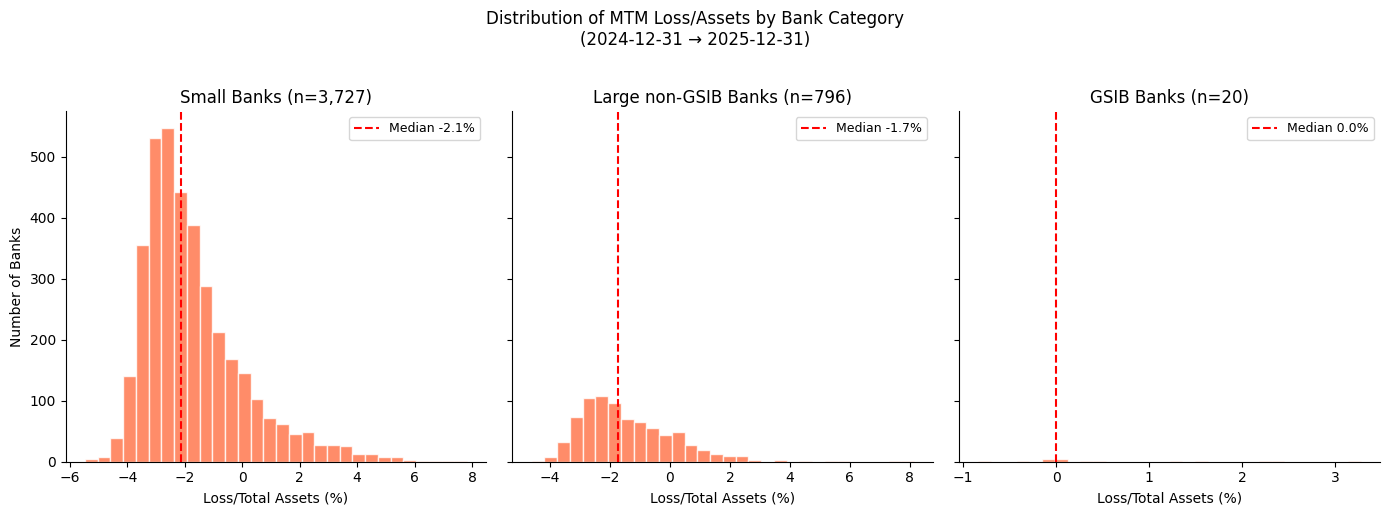

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, category in zip(axes, ["Small", "Large non-GSIB", "GSIB"]):
    mask = bank_losses["size_category"] == category
    subset = bank_losses.loc[mask, "loss_over_assets"].dropna() * 100
    ax.hist(subset, bins=30, color="#FF7043", edgecolor="white", alpha=0.8)
    ax.axvline(subset.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median {subset.median():.1f}%")
    ax.set_xlabel("Loss/Total Assets (%)")
    ax.set_title(f"{category} Banks (n={mask.sum():,})")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Number of Banks")
plt.suptitle(f"Distribution of MTM Loss/Assets by Bank Category\n({FFIEC_REPORT_DATE} → {FFIEC_MTM_END_DATE})", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_distribution_ffiec.png", dpi=150, bbox_inches="tight")
plt.show()

## Table A1: Balance Sheet Composition
**Panel A: Bank Asset Composition, Q1 2022**

| Statistic | (1) Aggregate | (2) Full Sample | (3) Small (≤1.384B) | (4) Large (non-GSIB) | (5) GSIB |
|---|---|---|---|---|---|
| **Total Asset ($)** | 24T | 5.0B  | 0.3B | 8.7B  | 370B  |
|  | | (74.7B) | (0.3B) | (18.8B) | (690B) |
| **Number of Banks** | 4,844 | 4,844 | 4,090 | 710 | 44 |
| ... | ... | ... | ... | ... | ... |
| **Reverse Repo** | 1.2 | 0.0  | 0.0  | 0.0  | 0.0  |
|  |  | (0.0) |(0.0) | (0.0) | (0.0) |

**Panel B: Bank Liability Composition, Q1 2022**

| Statistic | (1) Aggregate | (2) Full Sample | (3) Small (≤1.384B) | (4) Large (non-GSIB) | (5) GSIB |
|---|---|---|---|---|---|
| **Total Liability** | 90.5 | 89.8 | 89.8 | 89.9 | 89.1|
|  | | (3.2) | (3.3) | (2.7) | (4.0) |
| **Domestic Depoist** | 76.6 | 86.8| 87.1 | 85.9| 81.4 |
| ... | ... | ... | ... | ... | ... |
| **Retained Earning** | 4 | 6.8 | 7.0| 5.7  |4.8 |
|  |  | (4.0) |(4.1) | (3.1) | (3.4) |

In [6]:
rd = pd.Timestamp(FFIEC_REPORT_DATE)
quarter_label = f"Q{rd.quarter} {rd.year}"

def _fmt_table_a1(df):
    """Format Table A1 for notebook display with appropriate units."""
    formatted = df.copy().astype(object)
    for idx in formatted.index:
        for col in formatted.columns:
            v = formatted.loc[idx, col]
            if pd.isna(v):
                formatted.loc[idx, col] = ""
            elif "Total Asset" in str(idx):
                abs_v = abs(v)
                if abs_v >= 1e9:
                    formatted.loc[idx, col] = f"{v/1e9:.1f}T"
                elif abs_v >= 1e6:
                    formatted.loc[idx, col] = f"{v/1e6:.1f}B"
                elif abs_v >= 1e3:
                    formatted.loc[idx, col] = f"{v/1e3:.1f}M"
                else:
                    formatted.loc[idx, col] = f"{v:.1f}K"
            elif "Number of Banks" in str(idx):
                formatted.loc[idx, col] = f"{int(v):,}"
            else:
                formatted.loc[idx, col] = f"{v:.1f}"
    return formatted

print("=" * 60)
print(f"TABLE A1: Balance Sheet Composition ({quarter_label})")
print("=" * 60)

print("-" * 60)
print(f"Panel A: Bank Asset Composition, {quarter_label}")
print("-" * 60)
print(_fmt_table_a1(table_a1_a).to_string())

print("-" * 60)
print(f"Panel B: Bank Liability Composition, {quarter_label}")
print("-" * 60)
print(_fmt_table_a1(table_a1_b).to_string())

TABLE A1: Balance Sheet Composition (Q4 2024)
------------------------------------------------------------
Panel A: Bank Asset Composition, Q4 2024
------------------------------------------------------------
                             Aggregate Full sample(mean) Full sample(sd) small(mean) small(sd) large(mean) large(sd) GSIB(mean) GSIB(sd)
Total Asset $                    24.1T              1.0B            1.6B      362.1M    292.6M        8.4B     12.8B     494.6B   884.2B
Number of Banks                  4,543             4,543                       3,727                   796                   20         
Cash                              11.2               8.2             6.7         8.5       7.0         6.4       5.0       25.1     24.8
Security                          21.0              17.4            13.0        18.2      13.6        13.6       8.9        9.8     12.0
Treasury                           5.5               0.0             0.0         0.0       0.0         0.0

## Figure A1: Aggregate Bank Balance Sheet

Stacked bar chart showing asset composition (top) and
liability + equity composition (bottom) for Q4 2024.

Saved: /Users/summer/p08_jiang_et_al_2024/_output/figure_a1_ffiec.pdf
Saved: /Users/summer/p08_jiang_et_al_2024/_output/figure_a1_ffiec.png


/Users/summer/p08_jiang_et_al_2024/src/create_figure_a1.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


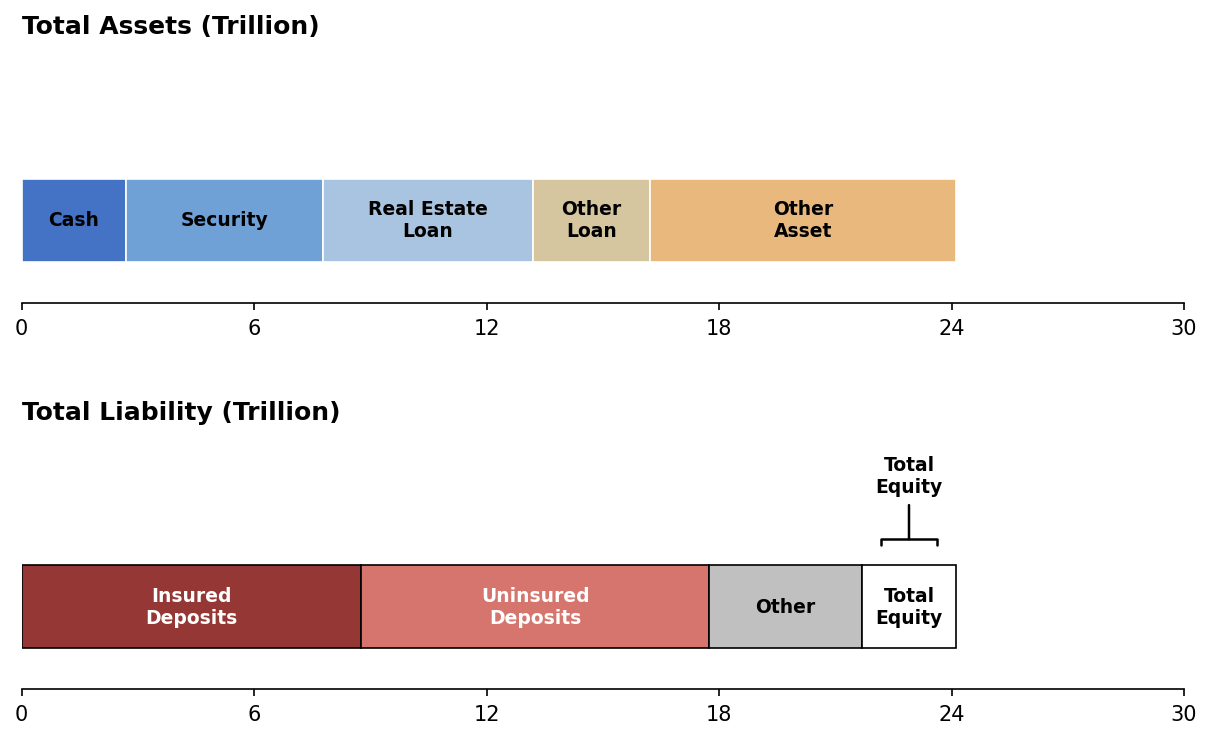

In [7]:
from create_figure_a1 import create_figure_a1
create_figure_a1(source="ffiec")

# Display saved figure
from IPython.display import Image
Image(str(OUTPUT_DIR / "figure_a1_ffiec.png"))